# Логистическая регрессия
## Данные о качестве красного вина (Red Wine Quality)

Датасет: [Kaggle — Red Wine Quality](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009)

**Целевая переменная:** `quality` — оценка качества вина от 3 до 8.

**Признаки:**
| Признак | Описание |
|---|---|
| `fixed acidity` | Фиксированная кислотность |
| `volatile acidity` | Летучая кислотность |
| `citric acid` | Лимонная кислота |
| `residual sugar` | Остаточный сахар |
| `chlorides` | Хлориды |
| `free sulfur dioxide` | Свободный диоксид серы |
| `total sulfur dioxide` | Общий диоксид серы |
| `density` | Плотность |
| `pH` | Кислотность pH |
| `sulphates` | Сульфаты |
| `alcohol` | Содержание алкоголя |

В ноутбуке решаются две задачи:
- **Бинарная классификация**: хорошее вино (quality ≥ 6) vs. плохое (quality < 6)
- **Многоклассовая классификация**: низкое / среднее / высокое качество (3 класса)

## Импорт библиотек

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# warnings.filterwarnings('ignore')

from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.multiclass import OneVsRestClassifier
from scipy import stats
from scipy.special import expit

## Загрузка данных

In [38]:
# df = pd.read_csv('./winequality-red.csv')

file_id = '1Sb3HGWMlKob3_-rEgqfudszz0ujhVTV9'
file_url = f'https://drive.google.com/uc?export=download&id={file_id}'
# Загружаем файл напрямую с URL в датафрейм
df = pd.read_csv(file_url)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [40]:
print('Пропущенные значения:', df.isnull().sum().sum())
df['quality'].value_counts().sort_index()

Пропущенные значения: 0


,count
quality,
3,10
4,53
5,681
6,638
7,199
8,18


**Наблюдение:** Оценки качества распределены неравномерно — большинство вин получают оценку 5 или 6.
Оценок 3 и 8 очень мало (10 и 18 соответственно).

## Сигмоида

В отличие от линейной регрессии, логистическая регрессия предсказывает **вероятность** принадлежности
к классу. Для этого используется **сигмоидная функция**, которая переводит любое вещественное число
в диапазон (0, 1).

In [41]:
def h(x, thetas):
    z = np.dot(x, thetas)
    return 1.0 / (1 + np.exp(-z))

При очень больших или малых значениях z возникает **переполнение** (overflow).
Проверим:

In [42]:
z = -999
print(f"np.exp(-z) = {np.exp(-z)}")              # inf — переполнение
print(f"1 / (1 + np.exp(-z)) = {1 / (1 + np.exp(-z))}")  # 0.0

z = 999
print(f"np.exp(-z) = {np.exp(-z)}")              # 0.0 — потеря значимости
print(f"1 / (1 + np.exp(-z)) = {1 / (1 + np.exp(-z))}")  # 1.0

np.exp(-z) = inf
1 / (1 + np.exp(-z)) = 0.0
np.exp(-z) = 0.0
1 / (1 + np.exp(-z)) = 1.0


/tmp/ipython-input-354/807140781.py:2: RuntimeWarning: overflow encountered in exp
  print(f"np.exp(-z) = {np.exp(-z)}")              # inf — переполнение
/tmp/ipython-input-354/807140781.py:3: RuntimeWarning: overflow encountered in exp
  print(f"1 / (1 + np.exp(-z)) = {1 / (1 + np.exp(-z))}")  # 0.0


Мы видим, что при z = −999 промежуточное значение np.exp(-z) становится inf — это и есть переполнение. При z = 999 значение np.exp(-z) сбрасывается до 0.0 — потеря значимости. В обоих случаях финальный результат сигмоиды оказался правильным (0.0 и 1.0), однако промежуточный inf опасен: при обучении на реальных данных он превращается в nan в градиентах, из-за чего веса модели перестают обновляться.

Поэтому нам нужна численно устойчивая реализация сигмоиды, которая никогда не вычисляет exp от больших чисел.

Для больших отрицательных z используем эквивалентную, но численно устойчивую формулу:
$$\sigma(z) = \frac{e^z}{e^z + 1}$$

In [43]:
z = -999
np.exp(z) / (np.exp(z) + 1)

np.float64(0.0)

In [44]:
def stable_sigmoid(z):
    if z >= 0:
        return 1 / (1 + np.exp(-z))
    else:
        return np.exp(z) / (np.exp(z) + 1)

In [45]:
# scipy предоставляет готовую устойчивую реализацию
expit(999), expit(-999)

(np.float64(1.0), np.float64(0.0))

In [46]:
def h(x, thetas):
    z = np.dot(x, thetas)
    return np.array([stable_sigmoid(value) for value in z])

Итог:

Мы решили проблему переполнения, реализовав stable_sigmoid — функцию, которая выбирает формулу в зависимости от знака z: - при z ≥ 0 используется исходная формула 1 / (1 + e⁻ᶻ) — безопасна, так как exp(-z) не переполняется - при z < 0 используется альтернативная формула eᶻ / (eᶻ + 1) — безопасна, так как exp(z) тоже не переполняется                                    
                                              
Готовый аналог из библиотеки scipy — функция expit — работает по тому же принципу. В дальнейшем мы будем использовать stable_sigmoid внутри функции h, которая вычисляет прогнозные вероятности модели.

## Функция потерь: Log-Loss (бинарная кросс-энтропия)

Для оценки качества логистической регрессии используем **логарифмическую функцию потерь**.

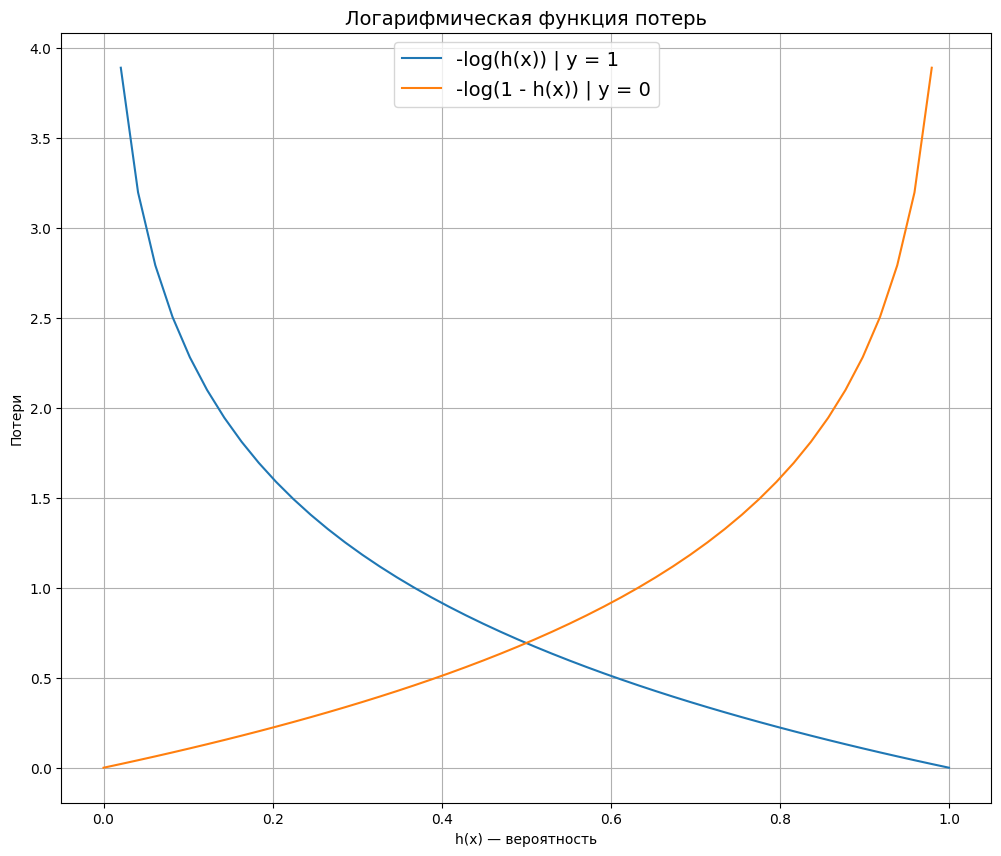

In [47]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    plt.figure(figsize=(12, 10))
    x_vals = np.linspace(0, 1)

    plt.plot(x_vals, -np.log(x_vals), label='-log(h(x)) | y = 1')
    plt.plot(x_vals, -np.log(1 - x_vals), label='-log(1 - h(x)) | y = 0')
    plt.legend(loc='upper center', prop={'size': 14})
    plt.title('Логарифмическая функция потерь', fontsize=14)
    plt.xlabel('h(x) — вероятность')
    plt.ylabel('Потери')
    plt.grid()
    plt.show()

На графике показаны две кривые штрафа:        
                                                                                                                                                     
  - Синяя (-log(h(x)) | y = 1) — используется когда правильный ответ класс 1 (например, хорошее вино). Ось x — это вероятность, которую предсказала  
  модель. Если модель предсказала вероятность 0.9 — она почти уверена в правильном ответе, штраф маленький. Если предсказала 0.1 — она почти уверена
  в неправильном ответе, штраф огромный.        
  - Оранжевая (-log(1 - h(x)) | y = 0) — используется когда правильный ответ класс 0 (например, плохое вино). Здесь логика обратная: модель должна
  предсказать низкую вероятность. Если предсказала 0.1 — правильно, штраф маленький. Если предсказала 0.9 — сильно ошиблась, штраф огромный.

  Итоговая функция потерь объединяет обе кривые в одну формулу и усредняет штрафы по всем наблюдениям — это и есть Log-Loss.

Рассмотрим пример вычисления функции потерь:

In [48]:
output = pd.DataFrame({
    'y':      [1, 1, 1, 0, 0, 1, 1, 0],
    'y_pred': [0.93, 0.81, 0.78, 0.43, 0.54, 0.49, 0.22, 0.1]
})
output

,y,y_pred
0,1,0.93
1,1,0.81
2,1,0.78
3,0,0.43
4,0,0.54
5,1,0.49
6,1,0.22
7,0,0.10


In [49]:
output['y=1 prob'] = np.where(output['y'] == 0, 1 - output['y_pred'], output['y_pred'])
output['-log'] = -np.log(output['y=1 prob'])
output

,y,y_pred,y=1 prob,-log
0,1,0.93,0.93,0.072571
1,1,0.81,0.81,0.210721
2,1,0.78,0.78,0.248461
3,0,0.43,0.57,0.562119
4,0,0.54,0.46,0.776529
5,1,0.49,0.49,0.713350
6,1,0.22,0.22,1.514128
7,0,0.10,0.90,0.105361


Для каждого наблюдения мы берём вероятность правильного ответа: если y=1 — берём y_pred напрямую, если y=0 — берём 1 - y_pred. Затем берём
  отрицательный логарифм этой вероятности — это и есть штраф за данное наблюдение. Чем меньше вероятность правильного класса, тем больше штраф.

In [50]:
output['-log'].mean()

np.float64(0.525404865908324)

Среднее по всем штрафам — это и есть итоговое значение Log-Loss для нашего примера. Чем оно меньше, тем лучше модель.

In [51]:
def objective(y, y_pred):
    y_one_loss  = y * np.log(y_pred + 1e-9)
    y_zero_loss = (1 - y) * np.log(1 - y_pred + 1e-9)
    return -np.mean(y_one_loss + y_zero_loss)

def gradient(x, y, y_pred, n):
    return np.dot(x.T, (y_pred - y)) * (1/n)

In [52]:
objective(output['y'], output['y_pred'])

np.float64(0.5254048640061278)

Функция objective даёт тот же результат, что и ручной расчёт выше — это подтверждает корректность реализации. В дальнейшем именно эту функцию мы
  будем минимизировать в процессе обучения с помощью градиентного спуска.


---
# Часть 1. Бинарная классификация

## Постановка задачи

Преобразуем исходную целевую переменную в бинарную:
- **1 (хорошее вино):** quality ≥ 6
- **0 (плохое вино):** quality < 6

In [53]:
df['quality_binary'] = (df['quality'] >= 6).astype(int)
df['quality_binary'].value_counts()

,count
quality_binary,
1,855
0,744


### EDA (Exploratory Data Analysis)

Посмотрим на распределение признаков:

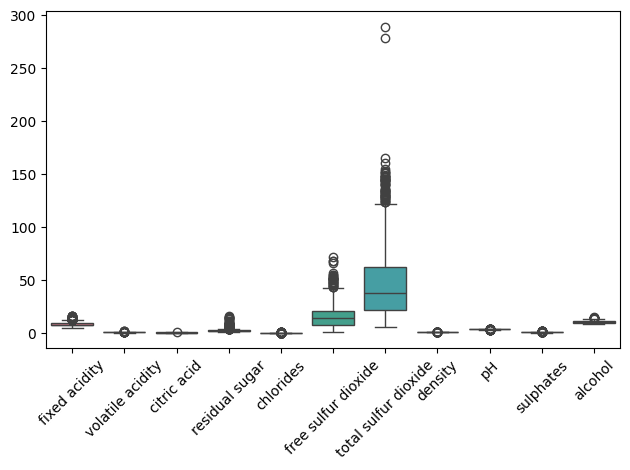

In [54]:
sns.boxplot(data=df.drop(columns=['quality', 'quality_binary']))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Выбор признаков

Используем **точечно-бисериальную корреляцию** — аналог корреляции Пирсона
для случая, когда одна переменная бинарная.

In [55]:
columns, correlations = [], []

for col in df.drop(columns=['quality', 'quality_binary']).columns:
    r, p = stats.pointbiserialr(df['quality_binary'], df[col])
    columns.append(col)
    correlations.append(r)

corr_df = pd.DataFrame({'feature': columns, 'r': correlations})
corr_df = corr_df.reindex(corr_df['r'].abs().sort_values(ascending=False).index)
corr_df.style.background_gradient(subset=['r'])

,feature,r
10,alcohol,0.434751
1,volatile acidity,-0.321441
6,total sulfur dioxide,-0.231963
9,sulphates,0.218072
2,citric acid,0.159129
7,density,-0.159110
4,chlorides,-0.109494
0,fixed acidity,0.095093
5,free sulfur dioxide,-0.061757
8,pH,-0.003264


**Наблюдение:** Наибольшую связь с качеством вина показывают:
- `alcohol` (r = 0.43) — больше алкоголя → выше качество
- `volatile acidity` (r = -0.32) — больше летучей кислотности → ниже качество

Используем эти два признака для построения модели.

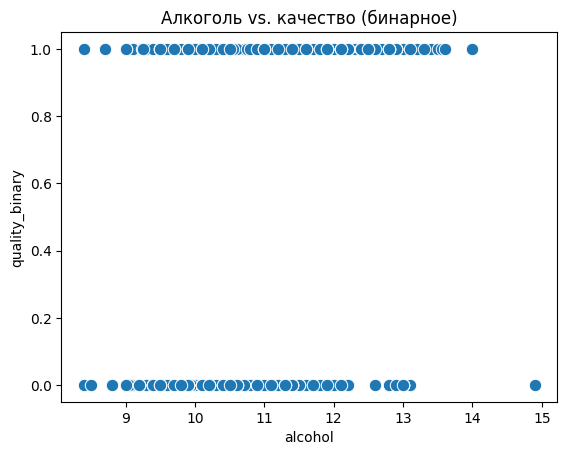

In [56]:
sns.scatterplot(x=df['alcohol'], y=df['quality_binary'], s=80)
plt.title('Алкоголь vs. качество (бинарное)')
plt.xlabel('alcohol')
plt.ylabel('quality_binary')
plt.show()

На графике видно, что вина с классом 1 (хорошее) в целом сдвинуты правее
  — то есть имеют более высокое содержание алкоголя. Однако классы сильно перекрываются, что говорит о том, что одного признака alcohol недостаточно
  для надёжного разделения.

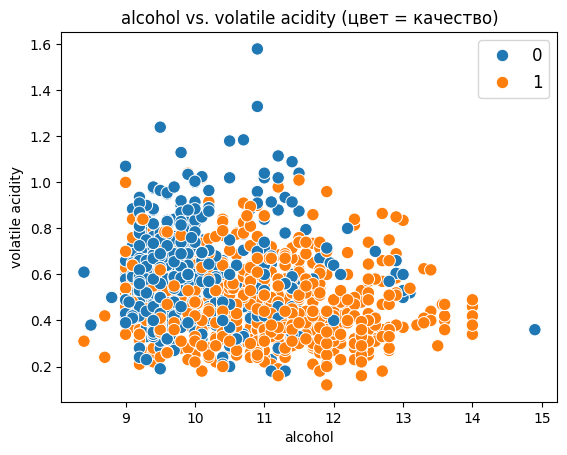

In [57]:
sns.scatterplot(x=df['alcohol'], y=df['volatile acidity'],
               hue=df['quality_binary'], s=80)
plt.legend(loc='upper right', prop={'size': 12})
plt.title('alcohol vs. volatile acidity (цвет = качество)')
plt.show()

На графике видна более чёткая закономерность: хорошие вина (оранжевые, класс 1)             
  концентрируются в правом нижнем углу — высокий алкоголь и низкая летучая кислотность. Плохие вина (синие, класс 0) чаще встречаются в левом верхнем
   углу — низкий алкоголь и высокая кислотность. Классы всё ещё перекрываются, но граница между ними уже прослеживается — именно её и будет искать
  логистическая регрессия.

### Подготовка данных

In [58]:
X = df[['alcohol', 'volatile acidity']].copy()
y = df['quality_binary']

# стандартизация
X = (X - X.mean()) / X.std()
X.head()

,alcohol,volatile acidity
0,-0.959946,0.961576
1,-0.584594,1.966827
2,-0.584594,1.296660
3,-0.584594,-1.384011
4,-0.959946,0.961576


In [59]:
X['alcohol'].mean(), X['alcohol'].std()

(np.float64(8.88733878374109e-17), 1.000000000000001)

## Обучение модели: градиентный спуск

Добавим столбец единиц (bias) и проведём обучение:

In [60]:
def add_ones(x):
    return x.insert(0, 'x0', np.ones(x.shape[0]))

add_ones(X)
X.head()

,x0,alcohol,volatile acidity
0,1.0,-0.959946,0.961576
1,1.0,-0.584594,1.966827
2,1.0,-0.584594,1.296660
3,1.0,-0.584594,-1.384011
4,1.0,-0.959946,0.961576


In [61]:
thetas, n = np.zeros(X.shape[1]), X.shape[0]
thetas, n

(array([0., 0., 0.]), 1599)

In [62]:
loss_history = []

for i in range(20000):
    y_pred = h(X, thetas)
    loss_history.append(objective(y, y_pred))
    grad = gradient(X, y, y_pred, n)
    thetas -= 0.1 * grad

thetas, loss_history[-1]

(array([ 0.25872045,  1.07065912, -0.63409289]), np.float64(0.54799955127679))

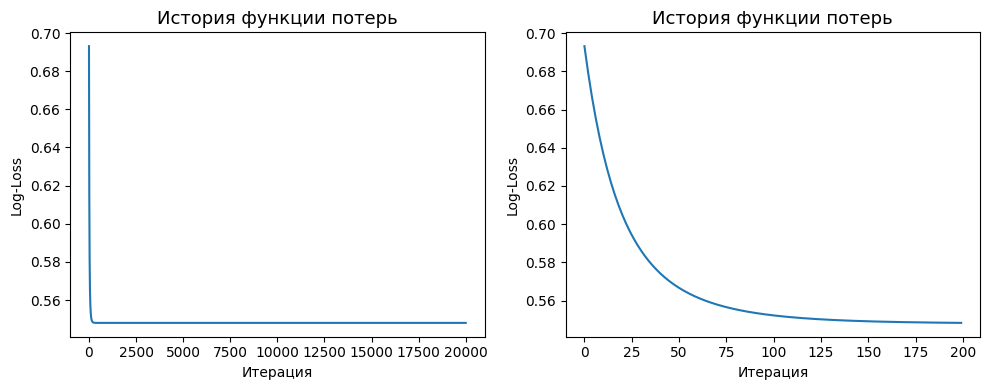

In [63]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title('История функции потерь', fontsize=13)
plt.xlabel('Итерация')
plt.ylabel('Log-Loss')

plt.subplot(1, 2, 2)
plt.plot(loss_history[:200])
plt.title('История функции потерь', fontsize=13)
plt.xlabel('Итерация')
plt.ylabel('Log-Loss')

plt.tight_layout()
plt.show()

Функция потерь снизилась с ~0.69 до ~0.55 и вышла на плато — это означает, что модель сошлась и дальнейшее увеличение числа итераций не даст       
  заметного улучшения.                                                                                                                               
                                                                                                                                                     
  Правый график (первые 200 итераций) показывает, что основное снижение ошибки происходит в самом начале — примерно до 100-й итерации функция потерь
  падает наиболее резко, после чего улучшения становятся всё меньше с каждым шагом.  

## Предсказание и оценка качества

In [64]:
def predict(x, thetas):
    z = np.dot(x, thetas)
    probs = np.array([stable_sigmoid(value) for value in z])
    y_pred = (probs >= 0.5).astype(int)
    return y_pred, probs

y_pred, probs = predict(X, thetas)
y_pred[0], probs[0]

(np.int64(0), np.float64(0.20120457795323798))

Функция predict вычисляет вероятность принадлежности к классу 1 для каждого наблюдения и применяет порог 0.5: если вероятность ≥ 0.5 —
  присваивается класс 1 (хорошее вино), иначе — класс 0. Для первого наблюдения выводится предсказанный класс и соответствующая вероятность.

In [65]:
accuracy_score(y, y_pred)

0.7379612257661038

Accuracy — доля правильно классифицированных наблюдений. Значение показывает, какой процент вин модель отнесла в правильный класс.

In [66]:
pd.DataFrame(confusion_matrix(y, y_pred),
             columns=['Forecast 0', 'Forecast 1'],
             index=['Actual 0', 'Actual 1'])

,Forecast 0,Forecast 1
Actual 0,561,183
Actual 1,236,619


Матрица ошибок показывает детальную картину ошибок модели:
  - 561 — плохих вин правильно распознано как плохие
  - 619 — хороших вин правильно распознано как хорошие
  - 183 — плохих вин ошибочно отнесено к хорошим
  - 236 — хороших вин ошибочно отнесено к плохим

## Граница принятия решений

Найдём уравнение разделяющей прямой и отобразим её на графике.

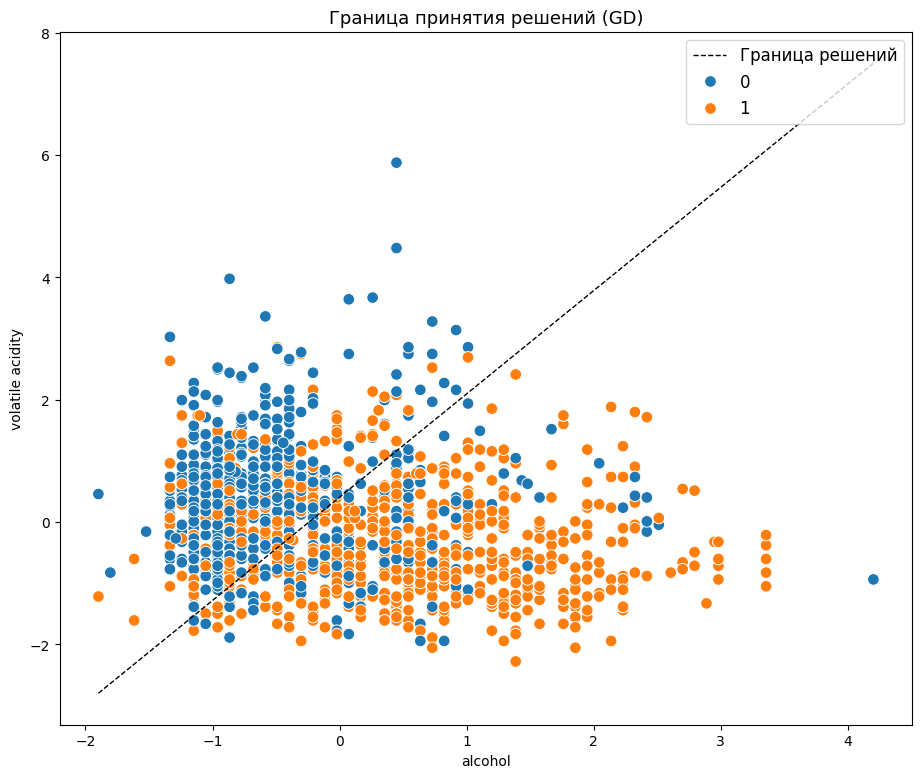

In [67]:
c, m = -thetas[0]/thetas[2], -thetas[1]/thetas[2]
xmin, xmax = X['alcohol'].min(), X['alcohol'].max()
xd = np.array([xmin, xmax])
yd = m * xd + c

plt.figure(figsize=(11, 9))
plt.plot(xd, yd, 'k', lw=1, ls='--', label='Граница решений')
sns.scatterplot(x=X['alcohol'], y=X['volatile acidity'], hue=y, s=70)
plt.legend(loc='upper right', prop={'size': 12})
plt.title('Граница принятия решений (GD)', fontsize=13)
plt.show()

## sklearn: LogisticRegression

In [68]:
X = df[['alcohol', 'volatile acidity']].copy()
y = df['quality_binary']
X = (X - X.mean()) / X.std()

sklearn_model = LogisticRegression()
sklearn_model.fit(X, y)
sklearn_model.intercept_, sklearn_model.coef_

(array([0.25743556]), array([[ 1.06488386, -0.63147605]]))

 sklearn нашёл практически те же веса, что и наша реализация: intercept = 0.257 (vs 0.259), alcohol = 1.065 (vs 1.071), volatile acidity = −0.631 (vs −0.634). Незначительные различия объясняются тем, что sklearn использует более продвинутый алгоритм оптимизации.

In [69]:
y_pred = sklearn_model.predict(X)
probs = sklearn_model.predict_proba(X)
y_pred[0], probs[0]

(np.int64(0), array([0.79770428, 0.20229572]))

Для первого наблюдения модель предсказала класс 0 (плохое вино) с вероятностью 79.8%. Вероятность хорошего вина — 20.2%. Так как 20.2% < 50%,
  применяется порог 0.5 и наблюдение относится к классу 0.

In [70]:
accuracy_score(y, y_pred)

0.7379612257661038

In [71]:
pd.DataFrame(confusion_matrix(y, y_pred),
             columns=['Forecast 0', 'Forecast 1'],
             index=['Actual 0', 'Actual 1'])

,Forecast 0,Forecast 1
Actual 0,561,183
Actual 1,236,619


Accuracy 73.8% и матрица ошибок полностью совпадают с результатами нашего класса LogReg — это подтверждает, что реализация с нуля работает
  корректно.

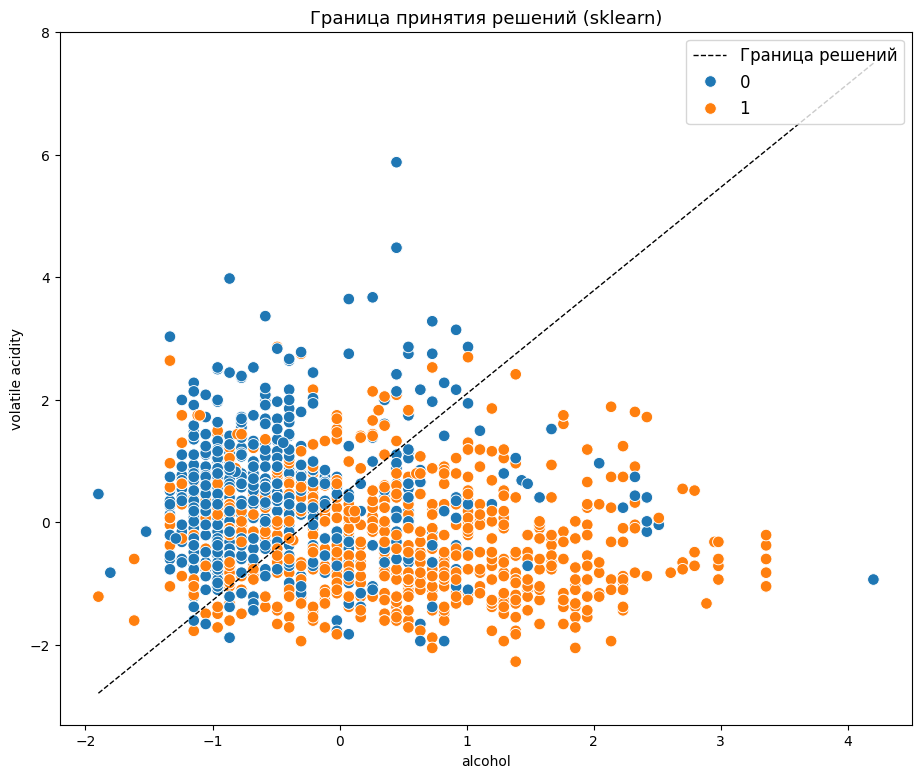

In [72]:
c, m = -sklearn_model.intercept_ / sklearn_model.coef_[0][1],               -sklearn_model.coef_[0][0] / sklearn_model.coef_[0][1]

xmin, xmax = X['alcohol'].min(), X['alcohol'].max()
xd = np.array([xmin, xmax])
yd = m * xd + c

plt.figure(figsize=(11, 9))
plt.plot(xd, yd, 'k', lw=1, ls='--', label='Граница решений')
sns.scatterplot(x=X['alcohol'], y=X['volatile acidity'], hue=y, s=70)
plt.legend(loc='upper right', prop={'size': 12})
plt.title('Граница принятия решений (sklearn)', fontsize=13)
plt.show()

На графике видна линейная граница — прямая, разделяющая классы. Хорошие вина (оранжевые) концентрируются правее и ниже линии (высокий алкоголь,
  низкая кислотность), плохие (синие) — левее и выше. Значительное перекрытие классов объясняет accuracy 73.8%: два признака недостаточно для чёткого
   разделения.

## Полиномиальные признаки + логистическая регрессия

In [73]:
X = df[['alcohol', 'volatile acidity']].copy()
y = df['quality_binary']
X = (X - X.mean()) / X.std()

polynomial_features = PolynomialFeatures(degree=2)
X_poly = polynomial_features.fit_transform(X)

poly_model = LogisticRegression()
poly_model.fit(X_poly, y)
y_pred = poly_model.predict(X_poly)
accuracy_score(y, y_pred)

0.7398373983739838

Добавление полиномиальных признаков 2-й степени дало accuracy 73.98% — незначительное улучшение по сравнению с линейной моделью (73.79%). Это говорит о том, что граница между классами в данных близка к линейной, и усложнение модели практически не помогает.

In [74]:
pd.DataFrame(confusion_matrix(y, y_pred),
             columns=['Forecast 0', 'Forecast 1'],
             index=['Actual 0', 'Actual 1'])

,Forecast 0,Forecast 1
Actual 0,561,183
Actual 1,233,622


По сравнению с линейной моделью матрица почти не изменилась: хороших вин стало распознаваться чуть больше (622 против 619), плохих — столько же (561). Ошибки второго рода (хорошие вина, отнесённые к плохим) сократились с 236 до 233.

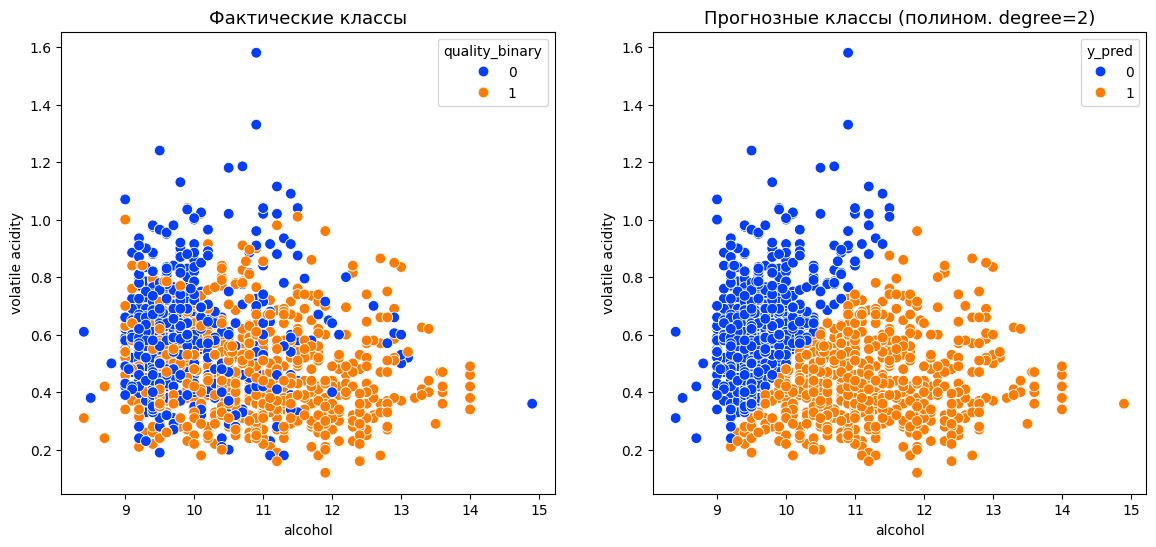

In [75]:
predictions = df[['alcohol', 'volatile acidity']].copy()
predictions['y_pred'] = y_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6),
                                gridspec_kw={'wspace': 0.2})

sns.scatterplot(data=df, x='alcohol', y='volatile acidity',
                hue='quality_binary', ax=ax1, s=60, palette='bright')
ax1.set_title('Фактические классы', fontsize=13)

sns.scatterplot(data=predictions, x='alcohol', y='volatile acidity',
                hue='y_pred', ax=ax2, s=60, palette='bright')
ax2.set_title('Прогнозные классы (полином. degree=2)', fontsize=13)

plt.show()

 На графиках видно, что прогнозная граница полиномиальной модели degree=2 стала слегка изогнутой — в отличие от прямой линии линейной модели. Однако из-за сильного перекрытия классов это изменение почти не влияет на качество классификации.

---
# Часть 2. Многоклассовая классификация

## Постановка задачи

Создадим три класса качества вина:
- **0 (низкое):** quality ≤ 5 — 744 наблюдения
- **1 (среднее):** quality = 6 — 638 наблюдений
- **2 (высокое):** quality ≥ 7 — 217 наблюдений

In [76]:
df['quality_class'] = pd.cut(df['quality'], bins=[2, 5, 6, 8],
                              labels=[0, 1, 2]).astype(int)
df['quality_class'].value_counts().sort_index()

,count
quality_class,
0,744
1,638
2,217


Классы распределены неравномерно: низкого качества — 744 вина, среднего — 638, высокого — всего 217. Дисбаланс классов означает, что модели будет
  сложнее распознавать редкий класс 2 — это скажется на результатах.

### Выбор признаков: корреляционное отношение

Для многоклассовой целевой переменной используем **корреляционное отношение** η —
меру связи между числовым и категориальным признаком.

In [77]:
def correlation_ratio(numerical, categorical):
    values = np.array(numerical)
    ss_total = np.sum((values.mean() - values) ** 2)

    cats = np.unique(categorical, return_inverse=True)[1]
    ss_betweengroups = 0

    for c in np.unique(cats):
        group = values[cats == c]
        ss_betweengroups += len(group) * (group.mean() - values.mean()) ** 2

    return np.sqrt(ss_betweengroups / ss_total)

In [78]:
# стандартизируем данные для анализа
df_scaled = df.copy()
df_scaled[df.drop(columns=['quality','quality_binary','quality_class']).columns] =     (df.drop(columns=['quality','quality_binary','quality_class']) -
     df.drop(columns=['quality','quality_binary','quality_class']).mean()) /     df.drop(columns=['quality','quality_binary','quality_class']).std()

columns, correlations = [], []
for col in df_scaled.drop(columns=['quality','quality_binary','quality_class']).columns:
    eta = correlation_ratio(df_scaled[col], df_scaled['quality_class'])
    columns.append(col)
    correlations.append(round(eta, 4))

eta_df = pd.DataFrame({'feature': columns, 'eta': correlations}).sort_values('eta', ascending=False)
eta_df.style.background_gradient(subset=['eta'])

,feature,eta
10,alcohol,0.509400
1,volatile acidity,0.360600
9,sulphates,0.252800
6,total sulfur dioxide,0.239100
2,citric acid,0.231200
7,density,0.187200
0,fixed acidity,0.131900
4,chlorides,0.125400
5,free sulfur dioxide,0.081200
8,pH,0.060400


**Наблюдение:** `alcohol` и `volatile acidity` снова имеют наибольшую связь
с классом качества — используем их для многоклассовой классификации.

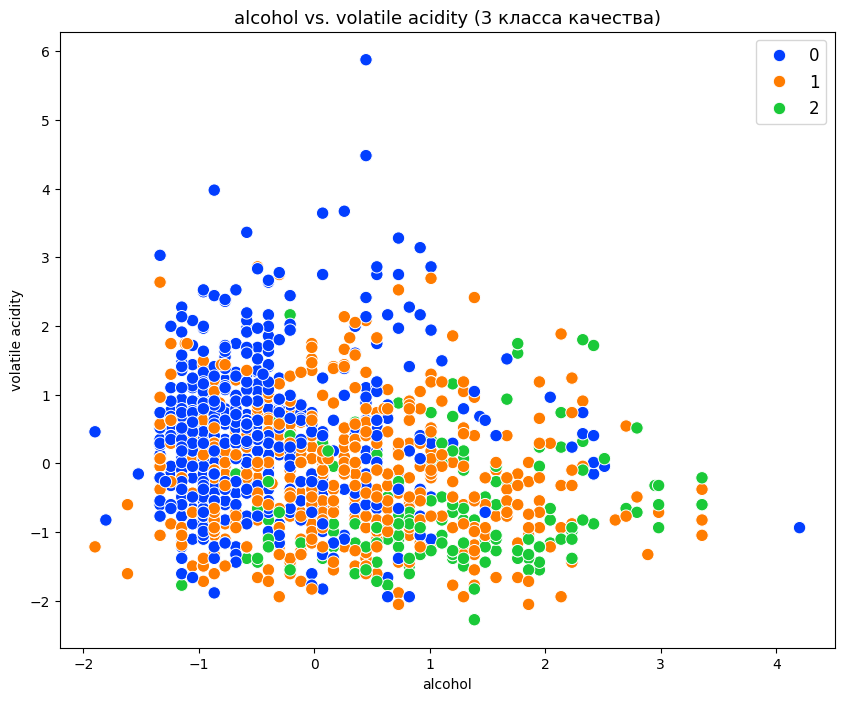

In [79]:
df_mc = df_scaled[['alcohol', 'volatile acidity', 'quality_class']].copy()

plt.figure(figsize=(10, 8))
sns.scatterplot(x=df_mc['alcohol'], y=df_mc['volatile acidity'],
                hue=df_mc['quality_class'], palette='bright', s=80)
plt.legend(loc='upper right', prop={'size': 12})
plt.title('alcohol vs. volatile acidity (3 класса качества)', fontsize=13)
plt.show()

На графике видно, что три класса сильно перекрываются. Высококачественные вина (класс 2) концентрируются в правом нижнем углу (высокий алкоголь,
  низкая кислотность), но значительно смешаны со средним классом. Это предсказывает более низкую точность по сравнению с бинарной задачей.

## One-vs-Rest (OVR): ручная реализация

**OVR (один против остальных)** — для каждого класса обучаем отдельный бинарный классификатор.
Итоговый класс — тот, чья модель дала наибольшую вероятность.

In [80]:
x1, x2 = 'alcohol', 'volatile acidity'
target = df_mc['quality_class'].unique()
target

array([0, 1, 2])

In [81]:
ovr_0, ovr_1, ovr_2 = df_mc.copy(), df_mc.copy(), df_mc.copy()

ovr_0['quality_class'] = np.where(df_mc['quality_class'] == 0, 1, 0)
ovr_1['quality_class'] = np.where(df_mc['quality_class'] == 1, 1, 0)
ovr_2['quality_class'] = np.where(df_mc['quality_class'] == 2, 1, 0)

ovr_0.head(3)

,alcohol,volatile acidity,quality_class
0,-0.959946,0.961576,1
1,-0.584594,1.966827,1
2,-0.584594,1.296660,1


In [82]:
models = []

for ovr_n in [ovr_0, ovr_1, ovr_2]:
    X = ovr_n[['alcohol', 'volatile acidity']]
    y = ovr_n['quality_class']

    model = LogReg()
    model.fit(X, y)
    models.append(model)

models[0].thetas

array([-0.25872045, -1.07065912,  0.63409289])

In [83]:
X = df_mc[['alcohol', 'volatile acidity']]
y = df_mc['quality_class']

probs = []
for model in models:
    _, prob = model.predict(X)
    probs.append(prob)

all_probs = np.concatenate(probs, axis=0).reshape(len(probs), -1).T
y_pred = np.argmax(all_probs, axis=1)

accuracy_score(y, y_pred)

0.6035021888680425

In [84]:
pd.DataFrame(confusion_matrix(y, y_pred),
             columns=['Forecast 0', 'Forecast 1', 'Forecast 2'],
             index=['Actual 0', 'Actual 1', 'Actual 2'])

,Forecast 0,Forecast 1,Forecast 2
Actual 0,609,134,1
Actual 1,295,321,22
Actual 2,23,159,35


Accuracy 60.35% — заметно ниже, чем в бинарной задаче (73.8%). Матрица ошибок показывает главную проблему: класс 2 (высокое качество) почти не
  распознаётся — из 217 вин правильно определено лишь 35. Большинство из них модель ошибочно относит к классу 1 (159 вин).

## sklearn: OneVsRestClassifier

In [85]:
X = df_mc[['alcohol', 'volatile acidity']]
y = df_mc['quality_class']

ovr_sklearn = OneVsRestClassifier(LogisticRegression())
ovr_sklearn.fit(X, y)
y_pred = ovr_sklearn.predict(X)
accuracy_score(y, y_pred)

0.6035021888680425

OneVsRestClassifier из sklearn реализует ту же логику OVR, но внутри библиотеки. Accuracy 60.35% полностью совпадает с нашими реализациями — ручной
   и через класс OVR_LogReg. Это финальное подтверждение корректности всех трёх реализаций: одна математика, один результат.

## Полиномиальные признаки + OVR

In [86]:
X = df_mc[['alcohol', 'volatile acidity']]
y = df_mc['quality_class']

polynomial_features = PolynomialFeatures(degree=7)
X_poly = polynomial_features.fit_transform(X)

poly_ovr_model = OneVsRestClassifier(LogisticRegression())
poly_ovr_model.fit(X_poly, y)
y_pred = poly_ovr_model.predict(X_poly)
accuracy_score(y, y_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

0.5934959349593496

 Полиномиальные признаки 7-й степени не улучшили результат — accuracy даже незначительно снизилась. Кроме того, появились предупреждения ConvergenceWarning: алгоритм не сошёлся за отведённые 100 итераций, то есть не нашёл оптимальные веса. Это говорит о том, что при такой степени полинома модель становится слишком сложной для данных, но лучше их не описывает.

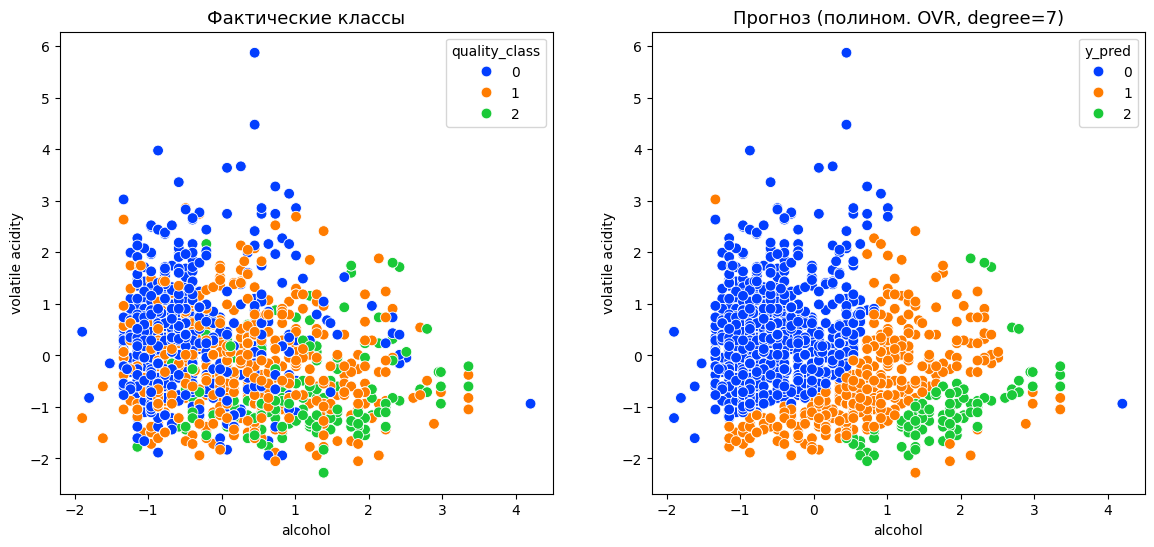

In [87]:
predictions = df_mc[['alcohol', 'volatile acidity']].copy()
predictions['y_pred'] = y_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6),
                                gridspec_kw={'wspace': 0.2})

sns.scatterplot(data=df_mc, x='alcohol', y='volatile acidity',
                hue='quality_class', ax=ax1, s=60, palette='bright')
ax1.set_title('Фактические классы', fontsize=13)

sns.scatterplot(data=predictions, x='alcohol', y='volatile acidity',
                hue='y_pred', ax=ax2, s=60, palette='bright')
ax2.set_title('Прогноз (полином. OVR, degree=7)', fontsize=13)

plt.show()

На правом графике видно, что граница между классами стала более сложной формы по сравнению с линейной OVR. Однако из-за сильного перекрытия классов в данных это усложнение не помогает — классы по-прежнему смешаны, а accuracy даже упала. Это классический пример переобучения: модель усложняется, но качество не растёт.

## Softmax-регрессия: реализация с нуля

**Softmax** — обобщение логистической регрессии на множество классов.
Для каждого наблюдения вычисляет вероятность принадлежности к каждому классу,
причём сумма вероятностей равна 1.

In [88]:
def add_ones(x):
    return x.insert(0, 'x0', np.ones(x.shape[0]))

X = df_mc[['alcohol', 'volatile acidity']].copy()
y = df_mc['quality_class']

add_ones(X)
X.head(3)

,x0,alcohol,volatile acidity
0,1.0,-0.959946,0.961576
1,1.0,-0.584594,1.966827
2,1.0,-0.584594,1.296660


Добавляем столбец единиц x0 — это свободный член (intercept). В отличие от бинарной логистической регрессии, где веса были вектором, здесь thetas —
   это матрица: каждый столбец содержит веса для одного класса.

In [89]:
def ohe(y):
    examples, features = y.shape[0], len(np.unique(y))
    zeros_matrix = np.zeros((examples, features))
    for idx, val in enumerate(y):
        zeros_matrix[idx, val] = 1
    return zeros_matrix

y_enc = ohe(df_mc['quality_class'])
y_enc[:3]

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

Целевую переменную преобразуем в матрицу из нулей и единиц (One-Hot Encoding): каждое наблюдение превращается в вектор [1,0,0], [0,1,0] или [0,0,1]
   в зависимости от класса. Первые три наблюдения принадлежат классу 0 — отсюда [1,0,0] в выводе.

In [90]:
def stable_softmax(x, thetas):
    z = np.dot(x, thetas)
    z = z - np.max(z, axis=-1, keepdims=True)
    numerator = np.exp(z)
    denominator = np.sum(numerator, axis=-1, keepdims=True)
    return numerator / denominator

In [91]:
def cross_entropy(probs, y_enc, epsilon=1e-9):
    n = probs.shape[0]
    return -np.sum(y_enc * np.log(probs + epsilon)) / n

def gradient_softmax(X, probs, y_enc):
    return np.dot(X.T, (y_enc - probs)) * (1 / probs.shape[0])

In [92]:
thetas = np.zeros((X.shape[1], 3))
loss_history = []

for i in range(30000):
    probs = stable_softmax(X, thetas)
    loss_history.append(cross_entropy(probs, y_enc))
    grad = gradient_softmax(X, probs, y_enc)
    thetas += 0.002 * grad

loss_history[0], loss_history[-1]

(np.float64(1.0986122856681098), np.float64(0.8055715810672179))

Функция потерь снизилась с 1.099 до 0.806 за 30 000 итераций. Начальное значение 1.099 — не случайное число: оно равно log(3) ≈ 1.099, что
  соответствует равномерному распределению вероятностей по трём классам при нулевых начальных весах. Это ожидаемая стартовая точка для любой
  многоклассовой модели с тремя классами.

In [93]:
y_pred = np.argmax(stable_softmax(X, thetas), axis=1)
accuracy_score(y, y_pred)

0.6128830519074422

In [94]:
pd.DataFrame(confusion_matrix(y, y_pred),
             columns=['Forecast 0', 'Forecast 1', 'Forecast 2'],
             index=['Actual 0', 'Actual 1', 'Actual 2'])

,Forecast 0,Forecast 1,Forecast 2
Actual 0,588,150,6
Actual 1,260,339,39
Actual 2,20,144,53


Softmax показал accuracy 61.29% — чуть лучше OVR (60.35%). Матрица ошибок показывает, что класс 2 (высокое качество) стал распознаваться немного
  лучше: 53 правильных предсказания против 35 у OVR. Классы 0 и 1 по-прежнему сильно перемешаны из-за перекрытия в признаковом пространстве.

## sklearn: LogisticRegression (multinomial)

In [95]:
X = df_mc[['alcohol', 'volatile acidity']]
y = df_mc['quality_class']

multi_model = LogisticRegression()
multi_model.fit(X, y)

y_pred = multi_model.predict(X)
accuracy_score(y, y_pred)

0.6135084427767354

LogisticRegression из sklearn по умолчанию использует многоклассовую стратегию и решает задачу напрямую как multinomial — в отличие от OVR, где обучались три отдельных бинарных классификатора. Accuracy 61.35% практически идентична Softmax с нуля (61.29%) — незначительная разница объясняется более продвинутым оптимизатором внутри sklearn.

In [96]:
pd.DataFrame(confusion_matrix(y, y_pred),
             columns=['Forecast 0', 'Forecast 1', 'Forecast 2'],
             index=['Actual 0', 'Actual 1', 'Actual 2'])

,Forecast 0,Forecast 1,Forecast 2
Actual 0,589,149,6
Actual 1,260,339,39
Actual 2,20,144,53


Матрица ошибок совпадает с результатами Softmax с нуля: 589 / 339 / 53 на главной диагонали. Это финальное подтверждение корректности нашей реализации SoftmaxLogReg — она даёт тот же результат, что и библиотечная функция.

## Итоговое сравнение моделей

На основе проделанной работы можно сдлать несколько выводов:
  - OVR (LogReg с нуля) и OVR (sklearn) дают одинаковый результат 60.35% — корректность ручной реализации подтверждена
  - Softmax незначительно превосходит OVR (~61.3% против ~60.4%) — для трёхклассовой задачи Softmax теоретически более подходящий подход, так как
  обучает все классы совместно, а не независимо
  - Полиномиальный OVR оказался хуже всех — усложнение модели при данных с сильным перекрытием классов приводит к ухудшению, а не улучшению
  - Общий уровень accuracy ~60-61% для всех моделей говорит о том, что узкое место — не алгоритм, а данные: двух признаков (alcohol и volatile
  acidity) недостаточно для надёжного разделения трёх классов